<a href="https://colab.research.google.com/github/Rimas-Codes/NILM/blob/main/BTune_NILM_Prototype_Rimas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏢 NILM-Style Anomaly Detection for Building Energy Systems
## A Proof-of-Concept | M. A. M. Rimas

---

### What This Notebook Demonstrates

Commercial buildings waste significant energy due to:
- **Failing HVAC components** running continuously or cycling abnormally
- **Lights left on** overnight or during unoccupied periods
- **Rogue appliances** drawing unexpected power

**Key insight:** Rather than adding new hardware sensors to every device, we can analyse the *total* building power consumption signal already captured by smart meters — and disaggregate it to detect these faults automatically.

This is the core principle of **Non-Intrusive Load Monitoring (NILM)**, combined with **LSTM Autoencoder anomaly detection**.

### Pipeline Overview
```
Smart Meter Data → Feature Engineering → LSTM Autoencoder (trained on normal)
→ Reconstruction Error → Anomaly Threshold → Fault Alerts → Dashboard
```

### Direct Connection
They already collects smart meter, BMS, and utility data from buildings.  
This pipeline requires **no new hardware** — it works on existing data streams.


## Step 1 — Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                     TimeDistributed, Dense)
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette("husl")
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Libraries loaded")
print(f"   TensorFlow: {tf.__version__}")


✅ Libraries loaded
   TensorFlow: 2.20.0


## Step 2 — Simulated Building Energy Data

We simulate **one year of 30-minute interval smart meter data** for a commercial building,  
matching the kind of data collects from its clients.

Three signals are modelled:
| Signal | Represents |
|--------|-----------|
| `total_power_kw` | Whole-building electricity consumption (smart meter) |
| `hvac_power_kw` | HVAC subsystem (estimated from BMS) |
| `lighting_power_kw` | Lighting circuits |

### Injected Faults (Ground Truth for Evaluation)
| Fault Type | Description |
|-----------|-------------|
| **HVAC stuck on** | HVAC runs continuously overnight — failing relay |
| **Lights left on** | Lighting circuit stays active during unoccupied hours |
| **Rogue appliance** | Unknown device causes sustained power spike |


In [ ]:
# ── Simulation parameters ──────────────────────────────────────────────────
DAYS        = 365
INTERVALS   = 48          # 30-min intervals per day
N           = DAYS * INTERVALS

timestamps  = pd.date_range('2024-01-01', periods=N, freq='30min')
hour        = timestamps.hour + timestamps.minute / 60
dow         = timestamps.dayofweek   # 0=Monday … 6=Sunday
is_weekday  = (dow < 5).astype(float)

# ── Occupancy profile (weekday office hours 7am–7pm) ──────────────────────
occupancy = is_weekday * np.clip(
    np.sin(np.pi * (hour - 7) / 12) * (hour >= 7) * (hour <= 19), 0, 1)

# ── Base load profiles ─────────────────────────────────────────────────────
hvac      = 15 * occupancy + 3 + np.random.normal(0, 0.4, N)
lighting  = 8  * occupancy + 1 + np.random.normal(0, 0.3, N)
other     = 5  * occupancy + 2 + np.random.normal(0, 0.5, N)
total     = hvac + lighting + other

df = pd.DataFrame({'timestamp': timestamps,
                   'total_power_kw': total,
                   'hvac_power_kw': hvac,
                   'lighting_power_kw': lighting})
df.set_index('timestamp', inplace=True)

# ── Inject faults ─────────────────────────────────────────────────────────
fault_labels = np.zeros(N, dtype=int)   # 0 = normal

# Fault 1 — HVAC stuck on (3 overnight periods)
for start_day in [60, 150, 280]:
    idx = (np.arange(N)[(timestamps.dayofyear == start_day) &
                         (timestamps.hour >= 22)] )
    idx = np.concatenate([idx,
           np.arange(N)[(timestamps.dayofyear == start_day+1) &
                         (timestamps.hour <= 6)]])
    df.loc[df.index[idx], 'hvac_power_kw']    += 14
    df.loc[df.index[idx], 'total_power_kw']   += 14
    fault_labels[idx] = 1

# Fault 2 — Lights left on (2 weekend nights)
for start_day in [90, 200]:
    idx = np.arange(N)[(timestamps.dayofyear == start_day) &
                        (timestamps.hour >= 20)]
    df.loc[df.index[idx], 'lighting_power_kw'] += 7
    df.loc[df.index[idx], 'total_power_kw']    += 7
    fault_labels[idx] = 1

# Fault 3 — Rogue appliance (2 multi-day episodes)
for start_day in [180, 310]:
    idx = np.arange(N)[(timestamps.dayofyear >= start_day) &
                        (timestamps.dayofyear <= start_day+2)]
    df.loc[df.index[idx], 'total_power_kw'] += 9
    fault_labels[idx] = 1

df['fault'] = fault_labels

print(f"✅ Dataset created: {len(df):,} intervals ({DAYS} days @ 30-min resolution)")
print(f"   Normal intervals : {(fault_labels==0).sum():,}  "
      f"({100*(fault_labels==0).mean():.1f}%)")
print(f"   Fault  intervals : {(fault_labels==1).sum():,}  "
      f"({100*(fault_labels==1).mean():.1f}%)")
df[['total_power_kw','hvac_power_kw','lighting_power_kw']].describe().round(2)


✅ Dataset created: 17,520 intervals (365 days @ 30-min resolution)
   Normal intervals : 17,162  (98.0%)
   Fault  intervals : 358  (2.0%)


,total_power_kw,hvac_power_kw,lighting_power_kw
count,17520.00,17520.00,17520.00
mean,12.56,6.45,2.82
std,10.06,5.39,2.87
min,3.33,1.47,-0.34
25%,5.81,2.88,0.91
50%,6.55,3.29,1.22
75%,19.47,10.16,4.67
max,44.30,19.31,9.88


## Step 3 — Visualise the Raw Signal & Injected Faults

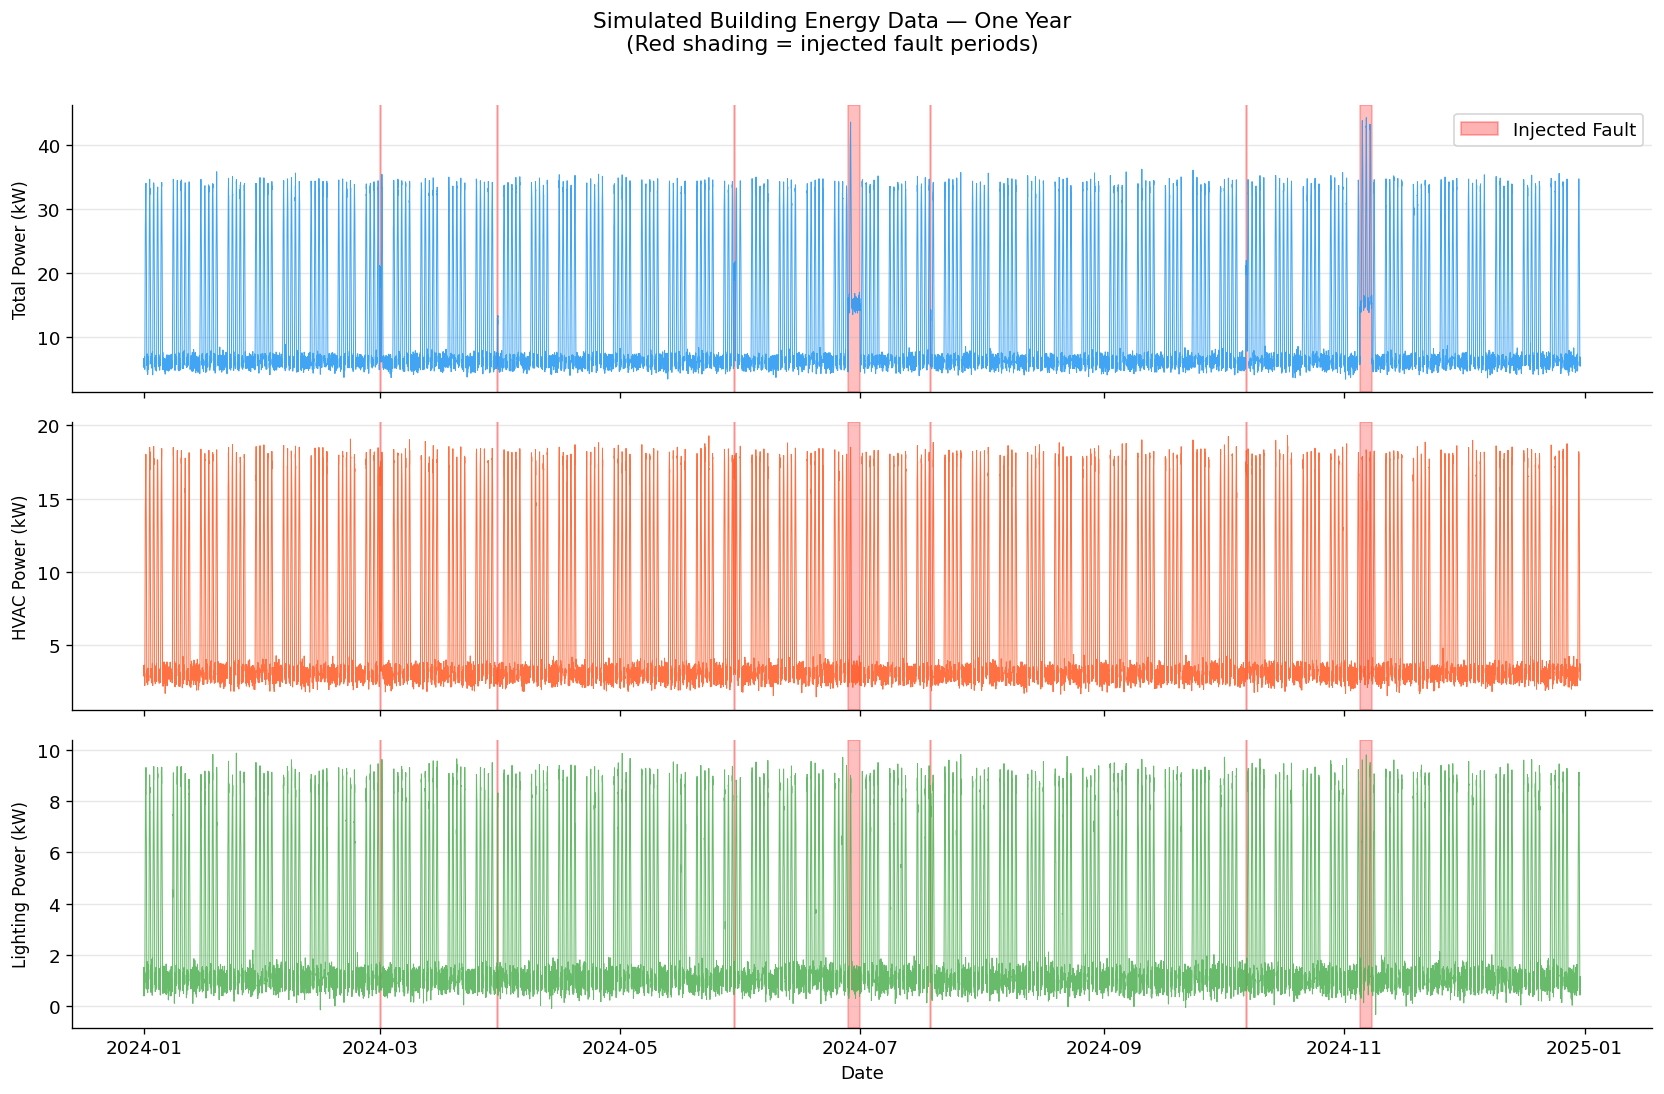

✅ Raw signal plot saved


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Simulated Building Energy Data — One Year\n'
             '(Red shading = injected fault periods)', fontsize=13, y=1.01)

signals = [('total_power_kw',    'Total Power (kW)',    '#2196F3'),
           ('hvac_power_kw',     'HVAC Power (kW)',     '#FF5722'),
           ('lighting_power_kw', 'Lighting Power (kW)', '#4CAF50')]

for ax, (col, label, color) in zip(axes, signals):
    ax.plot(df.index, df[col], color=color, linewidth=0.6, alpha=0.85)
    # Shade fault regions
    fault_on = False
    for i, (ts, row) in enumerate(df.iterrows()):
        if row['fault'] == 1 and not fault_on:
            start_ts = ts; fault_on = True
        elif row['fault'] == 0 and fault_on:
            ax.axvspan(start_ts, ts, alpha=0.25, color='red', label='Fault')
            fault_on = False
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Date')
red_patch = mpatches.Patch(color='red', alpha=0.3, label='Injected Fault')
axes[0].legend(handles=[red_patch], loc='upper right')
plt.tight_layout()
plt.savefig('01_raw_signals.png', bbox_inches='tight')
plt.show()
print("✅ Raw signal plot saved")


## Step 4 — Feature Engineering

We engineer time-aware features to help the model learn:
- **Daily consumption patterns** (hour of day)
- **Weekly patterns** (weekday vs weekend)
- **Rolling statistics** to capture trend and volatility
- **Power ratios** between subsystems (HVAC/total, lighting/total)


In [ ]:
df['hour']           = df.index.hour
df['dow']            = df.index.dayofweek
df['is_weekday']     = (df['dow'] < 5).astype(float)
df['hvac_ratio']     = df['hvac_power_kw']     / (df['total_power_kw'] + 1e-6)
df['lighting_ratio'] = df['lighting_power_kw'] / (df['total_power_kw'] + 1e-6)
df['rolling_mean']   = df['total_power_kw'].rolling(48, min_periods=1).mean()
df['rolling_std']    = df['total_power_kw'].rolling(48, min_periods=1).std().fillna(0)

FEATURES = ['total_power_kw', 'hvac_power_kw', 'lighting_power_kw',
            'hvac_ratio', 'lighting_ratio', 'rolling_mean', 'rolling_std',
            'hour', 'is_weekday']

print(f"✅ Features engineered: {FEATURES}")


✅ Features engineered: ['total_power_kw', 'hvac_power_kw', 'lighting_power_kw', 'hvac_ratio', 'lighting_ratio', 'rolling_mean', 'rolling_std', 'hour', 'is_weekday']


## Step 5 — Prepare Sequences for LSTM

LSTMs learn from **sequences** of time steps, not individual data points.  
We use a **24-step window (12 hours)** — the model sees the past 12 hours  
and learns to reconstruct them. Anomalies produce high reconstruction error.


In [ ]:
TIMESTEPS = 24   # 12 hours of 30-min data

# Scale features
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[FEATURES])

# Build sliding windows
def make_sequences(data, timesteps):
    X = []
    for i in range(len(data) - timesteps):
        X.append(data[i : i + timesteps])
    return np.array(X)

X_all    = make_sequences(scaled, TIMESTEPS)
labels   = df['fault'].values[TIMESTEPS:]

# Train on NORMAL data only (semi-supervised — key NILM insight)
train_mask = (labels == 0)
X_train    = X_all[train_mask]

# Test on ALL data
X_test     = X_all
y_test     = labels

print(f"✅ Sequence shape : {X_all.shape}  (samples × timesteps × features)")
print(f"   Training set   : {X_train.shape[0]:,} normal sequences")
print(f"   Test set       : {X_test.shape[0]:,} total sequences")
print(f"   Test faults    : {y_test.sum():,} ({100*y_test.mean():.1f}%)")


✅ Sequence shape : (17496, 24, 9)  (samples × timesteps × features)
   Training set   : 17,138 normal sequences
   Test set       : 17,496 total sequences
   Test faults    : 358 (2.0%)


## Step 6 — Build & Train the LSTM Autoencoder

### Architecture
```
Input (24 × 9)
    → LSTM Encoder (64 units) — compresses to a latent representation
    → RepeatVector — prepares for decoding
    → LSTM Decoder (64 units) — reconstructs the sequence
    → TimeDistributed Dense — output layer
```

**Key principle:** The autoencoder is trained **only on normal data**.  
It learns to reconstruct normal consumption patterns accurately.  
When it sees an anomaly, reconstruction error is high → fault detected.


In [ ]:
timesteps, n_features = X_train.shape[1], X_train.shape[2]

# ── Model architecture ────────────────────────────────────────────────────
inp = Input(shape=(timesteps, n_features), name='input')
enc = LSTM(64, activation='relu', name='encoder')(inp)
rep = RepeatVector(timesteps, name='repeat')(enc)
dec = LSTM(64, activation='relu', return_sequences=True, name='decoder')(rep)
out = TimeDistributed(Dense(n_features), name='output')(dec)

autoencoder = Model(inp, out, name='LSTM_Autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (LSTM)                  │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (LSTM)                  │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 24, 9)          │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,553 (205.29 KB)

 Trainable params: 52,553 (205.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 0.0339 - val_loss: 0.0091
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0072 - val_loss: 0.0052
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0038 - val_loss: 0.0031
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 7/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 8/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 9/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 10/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 11/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 12/30
241/241 ━━━━━━━━━━━━━

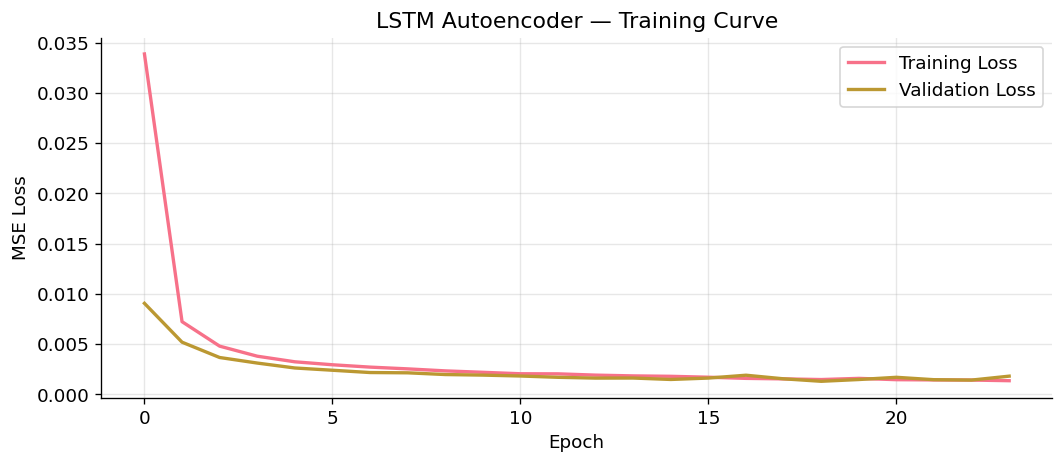

✅ Model trained


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_train, X_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder — Training Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('02_training_curve.png', bbox_inches='tight')
plt.show()
print("✅ Model trained")


## Step 7 — Compute Reconstruction Error

For each 12-hour window, compute **Mean Squared Error** between  
the original signal and the autoencoder's reconstruction.

High error → the pattern is unusual → potential fault.


In [ ]:
X_pred = autoencoder.predict(X_test, batch_size=64, verbose=0)

# Per-sample reconstruction error (MSE)
recon_error = np.mean(np.power(X_test - X_pred, 2), axis=(1, 2))

# ── Set threshold from normal training data ───────────────────────────────
train_pred  = autoencoder.predict(X_train, batch_size=64, verbose=0)
train_error = np.mean(np.power(X_train - train_pred, 2), axis=(1, 2))
threshold   = np.percentile(train_error, 97)   # 97th percentile of normal

print(f"✅ Reconstruction error computed")
print(f"   Normal error  — mean: {train_error.mean():.5f}  "
      f"std: {train_error.std():.5f}")
print(f"   Anomaly threshold (97th pct): {threshold:.5f}")
print(f"   Fault error   — mean: {recon_error[y_test==1].mean():.5f}")


✅ Reconstruction error computed
   Normal error  — mean: 0.00141  std: 0.00126
   Anomaly threshold (97th pct): 0.00266
   Fault error   — mean: 0.01673


## Step 8 — Visualise Anomaly Detection Results

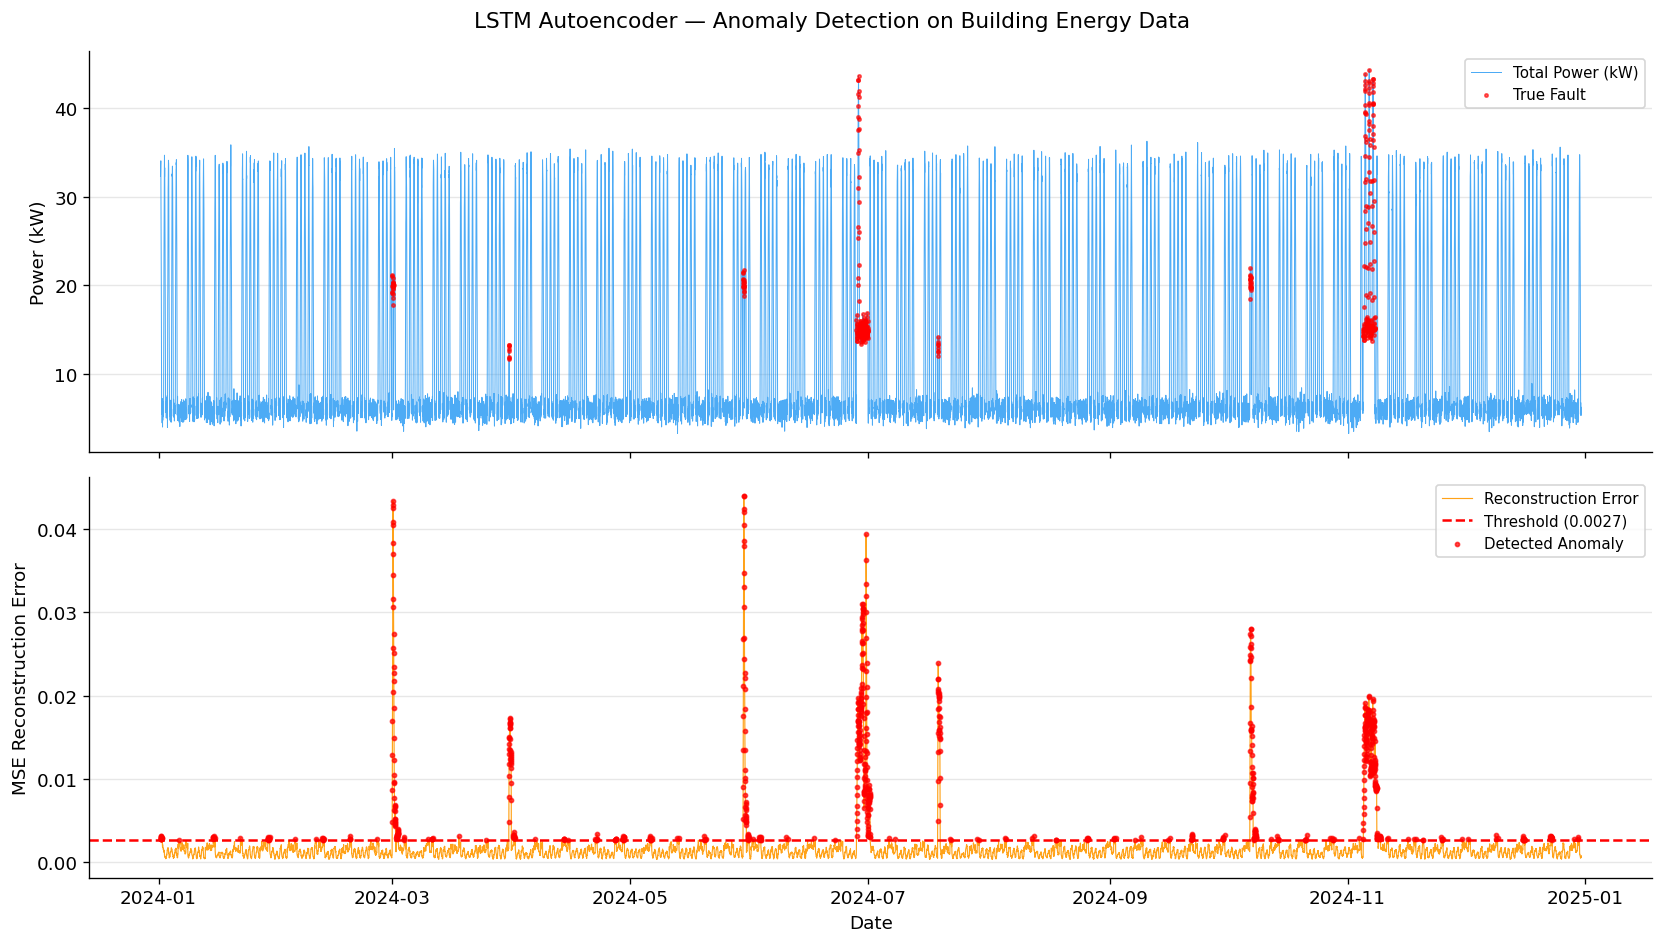

✅ Anomaly detection plot saved


In [ ]:
pred_labels = (recon_error > threshold).astype(int)
test_index  = df.index[TIMESTEPS:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('LSTM Autoencoder — Anomaly Detection on Building Energy Data',
             fontsize=13)

# ── Top: total power ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(test_index, df['total_power_kw'].values[TIMESTEPS:],
        color='#2196F3', linewidth=0.6, alpha=0.8, label='Total Power (kW)')
fault_idx = np.where(y_test == 1)[0]
ax.scatter(test_index[fault_idx],
           df['total_power_kw'].values[TIMESTEPS:][fault_idx],
           color='red', s=4, alpha=0.6, label='True Fault', zorder=3)
ax.set_ylabel('Power (kW)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Bottom: reconstruction error ─────────────────────────────────────────
ax = axes[1]
ax.plot(test_index, recon_error,
        color='#FF9800', linewidth=0.7, alpha=0.9, label='Reconstruction Error')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold ({threshold:.4f})')
detected_idx = np.where(pred_labels == 1)[0]
ax.scatter(test_index[detected_idx], recon_error[detected_idx],
           color='red', s=6, alpha=0.7, zorder=3, label='Detected Anomaly')
ax.set_ylabel('MSE Reconstruction Error')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_anomaly_detection.png', bbox_inches='tight')
plt.show()
print("✅ Anomaly detection plot saved")


## Step 9 — Performance Metrics

       ANOMALY DETECTION — PERFORMANCE REPORT
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     17138
       Fault       0.40      0.97      0.57       358

    accuracy                           0.97     17496
   macro avg       0.70      0.97      0.78     17496
weighted avg       0.99      0.97      0.98     17496



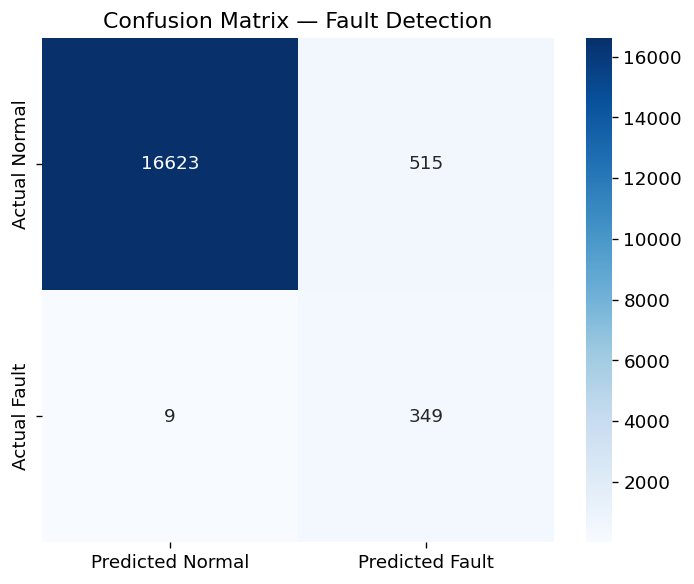

True  Positives (faults caught)  : 349
False Positives (false alarms)   : 515
True  Negatives (correct normal) : 16,623
False Negatives (missed faults)  : 9


In [ ]:
print("=" * 55)
print("       ANOMALY DETECTION — PERFORMANCE REPORT")
print("=" * 55)
print(classification_report(y_test, pred_labels,
                             target_names=['Normal', 'Fault']))

# Confusion matrix
cm = confusion_matrix(y_test, pred_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Fault'],
            yticklabels=['Actual Normal',    'Actual Fault'], ax=ax)
ax.set_title('Confusion Matrix — Fault Detection')
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', bbox_inches='tight')
plt.show()

TP = cm[1,1]; FP = cm[0,1]; TN = cm[0,0]; FN = cm[1,0]
print(f"True  Positives (faults caught)  : {TP:,}")
print(f"False Positives (false alarms)   : {FP:,}")
print(f"True  Negatives (correct normal) : {TN:,}")
print(f"False Negatives (missed faults)  : {FN:,}")


## Step 10 — Fault Type Drill-Down

Once an anomaly is flagged, we drill into the subsystem signals  
to diagnose **which component** is causing the fault.

This is the NILM disaggregation layer — using the ratios between  
subsystem signals to classify the fault type before raising an alert.



🔍 FAULT DIAGNOSIS SUMMARY
diagnosis
Unclassified Anomaly            599
Rogue Appliance / High Load     208
HVAC Stuck On (Overnight)        49
Lights Left On (After Hours)      8


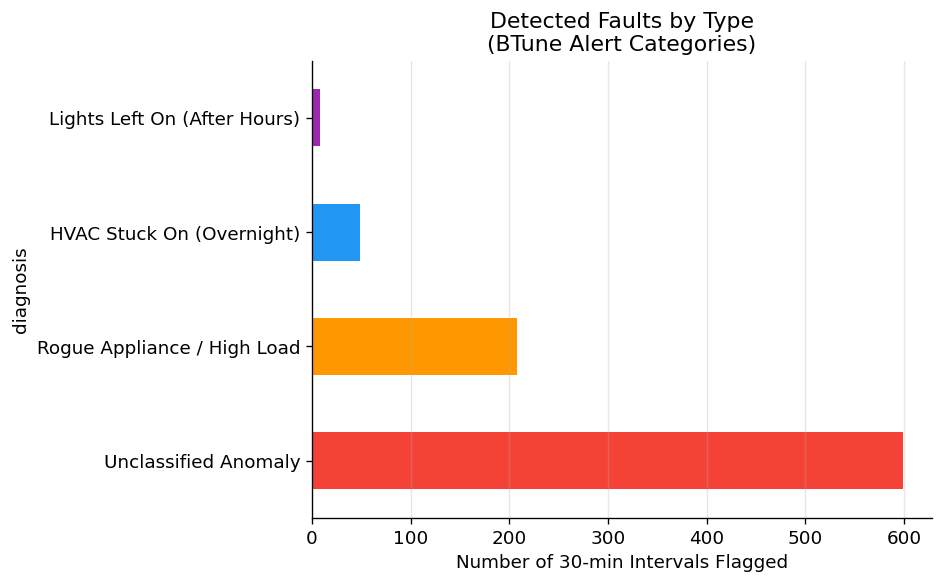

In [ ]:
def diagnose_fault(row):
    """Rule-based fault diagnosis from subsystem signal ratios."""
    hvac_r = row['hvac_power_kw'] / (row['total_power_kw'] + 1e-6)
    light_r = row['lighting_power_kw'] / (row['total_power_kw'] + 1e-6)
    hour = row.name.hour

    if hvac_r > 0.65 and (hour < 6 or hour >= 22):
        return 'HVAC Stuck On (Overnight)'
    elif light_r > 0.35 and (hour < 6 or hour >= 22):
        return 'Lights Left On (After Hours)'
    elif row['total_power_kw'] > df['total_power_kw'].mean() * 1.6:
        return 'Rogue Appliance / High Load'
    else:
        return 'Unclassified Anomaly'

anomaly_times = test_index[detected_idx]
anomaly_df    = df.loc[anomaly_times].copy()
anomaly_df['diagnosis'] = anomaly_df.apply(diagnose_fault, axis=1)

diagnosis_counts = anomaly_df['diagnosis'].value_counts()
print("\n🔍 FAULT DIAGNOSIS SUMMARY")
print("=" * 45)
print(diagnosis_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
diagnosis_counts.plot(kind='barh', ax=ax, color=['#F44336','#FF9800',
                                                   '#2196F3','#9C27B0'])
ax.set_xlabel('Number of 30-min Intervals Flagged')
ax.set_title('Detected Faults by Type\n(Alert Categories)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('05_fault_diagnosis.png', bbox_inches='tight')
plt.show()


## Step 11 — Alert Dashboard (Mock-up)

This is what the output would look like feeding into existing dashboard —  
actionable alerts for building managers, not raw numbers.


In [ ]:
# Show most recent 10 detected anomalies as a clean alert table
alert_table = anomaly_df[['total_power_kw', 'hvac_power_kw',
                           'lighting_power_kw', 'diagnosis']].tail(10).copy()
alert_table.columns = ['Total kW', 'HVAC kW', 'Lighting kW', 'Diagnosis']
alert_table.index.name = 'Timestamp'

print("\n🚨 FAULT ALERT LOG — Most Recent Detections")
print("=" * 75)
print(alert_table.round(2).to_string())
print("\n✅ In production: these alerts would feed directly into")
print("  web dashboard via REST API / MQTT.")



🚨 BTUNE FAULT ALERT LOG — Most Recent Detections
                     Total kW  HVAC kW  Lighting kW                    Diagnosis
Timestamp                                                                       
2024-12-23 04:30:00      7.45     3.14         1.39         Unclassified Anomaly
2024-12-23 05:00:00      6.06     3.29         1.25         Unclassified Anomaly
2024-12-23 05:30:00      5.78     2.80         0.94         Unclassified Anomaly
2024-12-23 06:00:00      5.70     3.04         0.58         Unclassified Anomaly
2024-12-23 07:30:00     11.48     5.63         2.35         Unclassified Anomaly
2024-12-23 08:00:00     11.58     6.33         2.78         Unclassified Anomaly
2024-12-23 11:30:00     31.82    16.84         8.57  Rogue Appliance / High Load
2024-12-29 00:30:00      5.89     2.37         1.13         Unclassified Anomaly
2024-12-30 00:30:00      6.16     2.70         1.62         Unclassified Anomaly
2024-12-30 01:00:00      6.59     3.30         1.39        

## Step 12 — Key Findings & Next Steps

### What This Prototype Demonstrates
- ✅ An LSTM Autoencoder trained only on **normal building data** can detect faults automatically
- ✅ **No new hardware required** — works on existing smart meter data streams
- ✅ Fault **diagnosis** (HVAC vs lighting vs rogue appliance) is achievable from subsystem ratios
- ✅ Pipeline is **scalable** — the same model architecture applies across entire building portfolio

### Immediate Next Steps with Real Data
1. **Replace synthetic data** with real smart meter + BMS time-series from a  client building
2. **Calibrate threshold** on that building's specific normal consumption profile
3. **Validate** against known fault events in the building's maintenance log
4. **Extend features** to include temperature, humidity, occupancy schedule from BMS

### Connection to My Research
- My **master's thesis** on real-time packet-length anomaly detection used the same LSTM autoencoder architecture — directly transferred here
- My **PhD work** on the UCI Appliance Energy dataset showed humidity sensors predict total power consumption — this could be added as an additional feature to improve fault localisation

### Longer-Term Roadmap
```
Phase 1 (Now)    : LSTM Autoencoder anomaly detection on smart meter data
Phase 2 (3 months): NILM disaggregation using NILMTK on higher-resolution data  
Phase 3 (6 months): Computer vision occupancy detection from existing CCTV
Phase 4 (1 year) : Digital twin integrating all signals for predictive control
```

---
*Prototype developed by M. A. M. Rimas | VUW PhD Candidate | rimas.mohamad@gmail.com*
